In [1]:
import os
from google.colab import drive

# 1. Drive'ı Mount Et (Eğer zaten bağlıysa 'Drive already mounted' der, sorun yok)
drive.mount('/content/drive')

# --- DÜZELTME BURADA ---
# Ekran görüntüsüne göre klasörün adı 'Bottleneck' (Büyük B)
# Yol: /content/drive/MyDrive/Bottleneck
BASE_DIR = '/content/drive/MyDrive/Bottleneck'

# Kontrol Bloğu: Dosyaların gerçekten orada olup olmadığını test edelim
print(f"Hedef Klasör: {BASE_DIR}")

if os.path.exists(BASE_DIR):
    print("✅ Klasör bulundu!")
    files = os.listdir(BASE_DIR)
    print("Klasör içindeki dosyalar:", files)

    # Zip dosyaları orada mı diye özel kontrol
    required_zips = ['FLAT_CMPL.zip', 'FLAT_RCL_PRE_2010.zip', 'FLAT_RCL_POST_2010.zip']
    missing_files = [f for f in required_zips if f not in files]

    if not missing_files:
        print("✅ Tüm ZIP dosyaları eksiksiz. Ana koda geçebilirsin.")
    else:
        print(f"❌ Şu dosyalar eksik: {missing_files}")
else:
    print("❌ Klasör hala bulunamadı. Lütfen dosya yolunu tekrar kontrol et.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Hedef Klasör: /content/drive/MyDrive/Bottleneck
✅ Klasör bulundu!
Klasör içindeki dosyalar: ['FLAT_CMPL.zip', 'FLAT_RCL_PRE_2010.zip', 'FLAT_RCL_POST_2010.zip']
✅ Tüm ZIP dosyaları eksiksiz. Ana koda geçebilirsin.


In [11]:
# @title Düzeltilmiş Script: Başlıksız Veri Okuma ve Sütun Eşleştirme
# Bu kod, header olmayan NHTSA dosyalarındaki doğru sütunları indeks numaralarıyla çeker.

import pandas as pd
import numpy as np
import os
import time
from google.colab import drive
from deep_translator import GoogleTranslator
from tqdm.auto import tqdm

# -------------------------------------------------------------------------
# 1. AYARLAR
# -------------------------------------------------------------------------
DRIVE_PATH = '/content/drive/MyDrive/Bottleneck'
CHECKPOINT_FILE = os.path.join(DRIVE_PATH, 'ceviri_checkpoint.csv')

FILE_CMPL = 'FLAT_CMPL.zip'
FILE_RCL_PRE = 'FLAT_RCL_PRE_2010.zip'
FILE_RCL_POST = 'FLAT_RCL_POST_2010.zip'

N_SAMPLES_CMPL = 40000
N_SAMPLES_RCL = 5000

# Çeviri Ayarları
SOURCE_LANG = 'en'
TARGET_LANG = 'tr'

# -------------------------------------------------------------------------
# 2. VERİ OKUMA VE SÜTUN ATAMA FONKSİYONLARI
# -------------------------------------------------------------------------

def load_complaints_fixed(zip_path, n_samples):
    print(f"\n[INFO] {zip_path} işleniyor (Headerless Mod)...")
    try:
        # header=None: İlk satırı başlık yapma, veri olarak al.
        df = pd.read_csv(os.path.join(DRIVE_PATH, zip_path),
                         compression='zip',
                         sep='\t',       # NHTSA verisi genelde TAB ile ayrılır
                         header=None,    # ÖNEMLİ: Başlık yok
                         encoding='latin-1',
                         on_bad_lines='skip',
                         low_memory=False)

        # Analizimize göre sütun indeksleri:
        # 2: Üretici (MFR_NAME)
        # 11: Arıza Parçası (COMPDESC)
        # 19: Şikayet Metni (CDESCR)

        # Sadece bu sütunları alıyoruz
        target_indices = [2, 19, 11]

        # Sütun sayısı kontrolü (Dosya bozuksa indeks hatası almamak için)
        if df.shape[1] <= max(target_indices):
            print(f"[HATA] Beklenen sütun sayısı yok. Dosyadaki sütun sayısı: {df.shape[1]}")
            return None

        df_clean = df.iloc[:, target_indices].copy()

        # İsimleri Biz Atıyoruz
        df_clean.columns = ['Üretici', 'Şikayet_Metni', 'Arıza_Parçası']

        # Rastgele Örneklem
        if len(df_clean) > n_samples:
            df_clean = df_clean.sample(n=n_samples, random_state=42)

        df_clean['Veri_Tipi'] = 'Şikayet'

        return df_clean

    except Exception as e:
        print(f"[HATA] Şikayet dosyası okunurken hata: {e}")
        return None

def load_recalls_fixed(path_pre, path_post, n_samples):
    print(f"\n[INFO] Recall verileri işleniyor (Headerless Mod)...")
    try:
        # Recall dosyaları için standart NHTSA formatı indeksleri:
        # 2: Üretici (MAKETXT veya MFGNAME)
        # 8: Arıza Parçası (COMPNAME)
        # 15: Kök Neden (DESC_DEFECT)
        # 17: Çözüm (REMEDY)
        recall_indices = [2, 15, 17, 8]

        col_names = ['Üretici', 'Kök_Neden', 'Çözüm', 'Arıza_Parçası']

        df_list = []
        for path in [path_pre, path_post]:
            full_path = os.path.join(DRIVE_PATH, path)
            if os.path.exists(full_path):
                temp_df = pd.read_csv(full_path, compression='zip', sep='\t', header=None, encoding='latin-1', on_bad_lines='skip', low_memory=False)

                # İndekslerin varlığını kontrol et
                if temp_df.shape[1] > max(recall_indices):
                    temp_clean = temp_df.iloc[:, recall_indices].copy()
                    temp_clean.columns = col_names
                    df_list.append(temp_clean)
                else:
                    print(f"[UYARI] {path} dosyasında yeterli sütun yok.")

        if not df_list:
            return None

        df_final = pd.concat(df_list, ignore_index=True)

        # Rastgele Örneklem
        if len(df_final) > n_samples:
            df_final = df_final.sample(n=n_samples, random_state=42)

        df_final['Veri_Tipi'] = 'Çözüm'
        return df_final

    except Exception as e:
        print(f"[HATA] Recall dosyaları okunurken hata: {e}")
        return None

# -------------------------------------------------------------------------
# 3. İŞ AKIŞI
# -------------------------------------------------------------------------

# 1. Drive Bağla (Zaten bağlıysa geçer)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Verileri Yükle ve Temizle
df_cmpl = load_complaints_fixed(FILE_CMPL, N_SAMPLES_CMPL)
df_rcl = load_recalls_fixed(FILE_RCL_PRE, FILE_RCL_POST, N_SAMPLES_RCL)

if df_cmpl is not None and df_rcl is not None:
    # İkisini Birleştir
    full_df = pd.concat([df_cmpl, df_rcl], ignore_index=True)

    # Sütun sırasını düzenle
    final_cols = ['Üretici', 'Şikayet_Metni', 'Arıza_Parçası', 'Kök_Neden', 'Çözüm', 'Veri_Tipi']
    full_df = full_df.reindex(columns=final_cols)

    # TEMİZLENMİŞ HAM VERİ ÇIKTISI (İLK 5 SATIR)
    print("\n" + "="*60)
    print("VERİ HAZIRLIĞI TAMAMLANDI - İLK 5 SATIR (Sütunlar Doğrulandı)")
    print("="*60)
    # NaN olan yerleri 'Yok' olarak gösterelim ki tablo okunsun
    print(full_df.head().fillna("-").to_markdown(index=False))

    print(f"\nToplam Veri Sayısı: {len(full_df)}")
    print("Sütunlar başarıyla izole edildi. Çeviriye geçiliyor...")

    # ---------------------------------------------------------------------
    # 4. ÇEVİRİ DÖNGÜSÜ (CHECKPOINT DESTEKLİ)
    # ---------------------------------------------------------------------

    # Checkpoint var mı?
    if os.path.exists(CHECKPOINT_FILE):
        saved_df = pd.read_csv(CHECKPOINT_FILE)
        start_idx = len(saved_df)
        print(f"\n[INFO] Checkpoint bulundu. {start_idx}. satırdan devam ediliyor.")
    else:
        start_idx = 0
        # Dosyayı oluştur ve header yaz
        pd.DataFrame(columns=final_cols).to_csv(CHECKPOINT_FILE, index=False)

    translator = GoogleTranslator(source=SOURCE_LANG, target=TARGET_LANG)

    # Sadece kalan veriyi al
    if start_idx < len(full_df):
        process_df = full_df.iloc[start_idx:]

        buffer = []
        save_counter = 0

        for i, row in tqdm(process_df.iterrows(), total=len(process_df), desc="Çeviri İlerlemesi"):
            try:
                # Satırı sözlüğe çevir (Pandas serisi üzerinde işlemden hızlıdır)
                row_dict = row.to_dict()

                # Çevrilecek alanlar
                fields_to_translate = ['Şikayet_Metni', 'Arıza_Parçası', 'Kök_Neden', 'Çözüm']

                for field in fields_to_translate:
                    text = str(row_dict.get(field, ''))
                    # Boş, NaN veya çok kısa metinleri çevirme
                    if text and text.lower() != 'nan' and text != '-' and len(text) > 3:
                        # Translate
                        translated_text = translator.translate(text)
                        row_dict[field] = translated_text
                        # time.sleep(0.1) # Gerekirse açılabilir

                buffer.append(row_dict)
                save_counter += 1

                # Her 100 satırda bir diske yaz (RAM şişmesin)
                if save_counter >= 100:
                    pd.DataFrame(buffer).to_csv(CHECKPOINT_FILE, mode='a', header=False, index=False)
                    buffer = []
                    save_counter = 0

            except Exception as e:
                print(f"Hata (Index {i}): {e}")
                time.sleep(2)

        # Kalanları yaz
        if buffer:
            pd.DataFrame(buffer).to_csv(CHECKPOINT_FILE, mode='a', header=False, index=False)

    print("\n" + "="*60)
    print("İŞLEM BİTTİ. Çevrilmiş Sonuç (İlk 5 Satır):")
    final_result = pd.read_csv(CHECKPOINT_FILE)
    print(final_result.head().to_markdown(index=False))

else:
    print("Veri yükleme başarısız olduğu için çeviriye geçilemedi.")


[INFO] FLAT_CMPL.zip işleniyor (Headerless Mod)...

[INFO] Recall verileri işleniyor (Headerless Mod)...

VERİ HAZIRLIĞI TAMAMLANDI - İLK 5 SATIR (Sütunlar Doğrulandı)
| Üretici                          | Şikayet_Metni                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

Çeviri İlerlemesi:   0%|          | 0/45000 [00:00<?, ?it/s]

Hata (Index 5571): 4 NEW TIRES INSTALLED AFTER 39,852 MILES IS UNACCEPTABLE --> No translation was found using the current translator. Try another translator?
Hata (Index 16514): DRIVER DOOR AJAR WARNING_.  HAVE TO SHUT THE DOOR NUMEROUS TIMES IN ORDER FOR THE WARNING TO GO OFF.  INTERIOR LIGHTS STAY ON UNTIL THE DOOR IS SHUT NUMEROUS TIME WHICH HAS GOTTEN TO BE REALLY A PAIN.  STARTED EXPERIENCING THIS PROBLEM JUST OUTSIDE THE VEHICLE MILEAGE WARRANTY.  DEALER HAS REFUSED TO REPAIR UNDER WARRANTY.  THIS SUCKS.  *TR	IVOQ	N		N	N	N						0														V		N	N
1121499	10648556	Chrysler (FCA US, LLC)	JEEP	LIBERTY	2006	N	20061212	N	0	0	ENGINE	LAREDO	TX	1J4GL485X6W	20141018	20141018	6500	1	ENGINE STALLS, SPUTTERS, NOT DRIVABLE, NO CHECK ENGINE LIGHT, DEALER HAD NO CLUE WHAT WAS WRONG. THIS CONDITION CONTINUED ON SEVERAL OTHER OCCASIONS AND VEHICLE HAD TO BE TOWED TO DEALERSHIP.   *TR	IVOQ	N		N	N	N	4	4WD				30														V		N	N
1121500	10648550	Nissan North America, Inc.	NISSAN	TITAN	2010	Y	

KeyboardInterrupt: 

In [4]:
# @title ADIM 1-C: Sütun Düzeltme ve Türkçe Kontrol Çevirisi
# Bu kod, kaymış sütunları düzeltir ve sonucu doğrulamak için 5 satırı Türkçeye çevirir.

import pandas as pd
from deep_translator import GoogleTranslator
from tqdm.auto import tqdm

# 1. SÜTUNLARI DÜZELT (Manuel Gözlem Sonucu)
# Paylaştığınız tabloya göre veriler şu sırada geliyor:
# [Üretici] - [Gereksiz Notlar] - [Kök Neden (Sorun)] - [Çözüm (Remedy)]

print("[BİLGİ] Sütunlar yeniden adlandırılıyor...")
# Mevcut df_recall hafızada ise onu kullan, yoksa checkpointten oku
if 'df_recall' not in locals():
    # Checkpoint dosyasını (eğer varsa) veya yeniden yükleme fonksiyonunu kullanabiliriz
    # Hızlıca hafızadakini varsayıyoruz, yoksa uyarı verecek.
    try:
        df_recall = pd.read_csv('/content/drive/MyDrive/Bottleneck/recall_ceviri_checkpoint.csv')
    except:
        print("Veri hafızada yok, lütfen bir önceki adımı tekrar çalıştırın.")

# Sütun isimlerini içeriğe göre düzeltiyoruz
df_recall.columns = ['Üretici', 'Gereksiz_Not', 'Kök_Neden', 'Çözüm']

# Gereksiz sütunu at ve sıralamayı düzelt
df_corrected = df_recall[['Üretici', 'Kök_Neden', 'Çözüm']].copy()

print(f"\n[DÜZELTİLDİ] Yeni Sütunlar: {df_corrected.columns.tolist()}")

# 2. TÜRKÇE ÇEVİRİ TESTİ (İLK 5 SATIR)
print("\n[İŞLEM] Doğrulama için ilk 5 satır Türkçeye çevriliyor...")

translator = GoogleTranslator(source='en', target='tr')
test_samples = df_corrected.head(5).copy()

for index, row in test_samples.iterrows():
    try:
        # Kök Neden Çevirisi
        sorun_eng = str(row['Kök_Neden'])
        if len(sorun_eng) > 3:
            test_samples.at[index, 'Kök_Neden'] = translator.translate(sorun_eng[:2000]) # Hız için limitli

        # Çözüm Çevirisi
        cozum_eng = str(row['Çözüm'])
        if len(cozum_eng) > 3:
            test_samples.at[index, 'Çözüm'] = translator.translate(cozum_eng[:2000])

    except Exception as e:
        print(f"Satır {index} çevrilirken hata: {e}")

# 3. SONUCU GÖSTER
print("\n" + "="*80)
print("TÜRKÇE ÇEVİRİ KONTROLÜ (Doğru Sütunlar)")
print("="*80)
# Markdown formatında yazdır (daha okunaklı)
print(test_samples.to_markdown(index=False))

print("\n\nEĞER YUKARIDAKİ TABLO MANTIKLIYSA:")
print("1. 'Kök_Neden' sütununda arızayı (Örn: Frenler tutmuyor)")
print("2. 'Çözüm' sütununda teknik müdahaleyi (Örn: Bayi parçayı değiştirecek)")
print("görüyorsanız veri hazırdır. Onay verin, tüm veriyi bu şekilde kaydedelim.")

[BİLGİ] Sütunlar yeniden adlandırılıyor...

[DÜZELTİLDİ] Yeni Sütunlar: ['Üretici', 'Kök_Neden', 'Çözüm']

[İŞLEM] Doğrulama için ilk 5 satır Türkçeye çevriliyor...

TÜRKÇE ÇEVİRİ KONTROLÜ (Doğru Sütunlar)
| Üretici     | Kök_Neden                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          | Çözüm                                                                                                                                                

In [ ]:
# @title ADIM 4: Birleştirme, 5.000 Örnek Seçme ve Çevirme
# Bu script:
# 1. İki ZIP dosyasını okur ve birleştirir.
# 2. Sütunları otomatik tespit eder.
# 3. Rastgele 5.000 satır seçer.
# 4. Sadece bu 5.000 satırı Türkçeye çevirip kaydeder.

import pandas as pd
import numpy as np
from deep_translator import GoogleTranslator
from tqdm.auto import tqdm
import zipfile

# İlerleme çubuğu
tqdm.pandas()

# DOSYA YOLLARI
zip_path_post = '/content/drive/MyDrive/Bottleneck/FLAT_RCL_POST_2010.zip'
zip_path_pre = '/content/drive/MyDrive/Bottleneck/FLAT_RCL_PRE_2010.zip'
output_path = '/content/drive/MyDrive/Bottleneck/RECALL_VERISI_5000_TR.csv'

print("[1/4] Dosyalar okunuyor ve birleştiriliyor...")

def read_zip_smart(zip_path):
    try:
        with zipfile.ZipFile(zip_path, 'r') as z:
            file_name = z.namelist()[0]
            # Önce pipe '|' ile dene
            try:
                df = pd.read_csv(z.open(file_name), sep='|', header=None, encoding='latin-1', on_bad_lines='skip', low_memory=False)
                if df.shape[1] < 2: raise ValueError()
                return df
            except:
                # Olmazsa Tab '\t' ile dene
                return pd.read_csv(z.open(file_name), sep='\t', header=None, encoding='latin-1', on_bad_lines='skip', low_memory=False)
    except Exception as e:
        print(f"Hata: {e}")
        return pd.DataFrame()

# Okuma ve Birleştirme
df_post = read_zip_smart(zip_path_post)
df_pre = read_zip_smart(zip_path_pre)
df_all = pd.concat([df_post, df_pre], ignore_index=True)

print(f"   -> Toplam Havuz: {len(df_all)} satır veriye ulaşıldı.")

# ---------------------------------------------------------
print("[2/4] Sütunlar analiz ediliyor (Üretici - Kök Neden - Çözüm)...")

# En uzun metin içeren sütunları bul (Kök Neden ve Çözüm genelde en uzunudur)
avg_lengths = df_all.astype(str).applymap(len).mean()
longest_cols = avg_lengths.nlargest(3).index.tolist()

# 0. Sütun genelde Üreticidir. Diğerleri uzunluğa göre belirlenir.
col_manufacturer = 0
col_root_cause = longest_cols[0] # En uzun
col_remedy = longest_cols[1]     # İkinci en uzun

if col_root_cause == col_remedy: col_remedy = longest_cols[2]

# Veriyi temizle ve sütunları ata
df_clean = df_all.iloc[:, [col_manufacturer, col_root_cause, col_remedy]].copy()
df_clean.columns = ['Üretici', 'Kök_Neden', 'Çözüm']
df_clean = df_clean.dropna()

# ---------------------------------------------------------
print("[3/4] Rastgele 5.000 satır seçiliyor...")

# Eğer veri 5000'den azsa hepsini al, çoksa rastgele seç
sample_size = min(5000, len(df_clean))
df_sample = df_clean.sample(n=sample_size, random_state=42).copy()

print(f"   -> {sample_size} adet satır çeviriye hazırlanıyor.")

# ---------------------------------------------------------
print("[4/4] Çeviri işlemi başlıyor (Bu işlem 3-5 dk sürebilir)...")

translator = GoogleTranslator(source='en', target='tr')

def guvenli_ceviri(text):
    try:
        text = str(text)[:4500] # Uzunluk limiti
        return translator.translate(text)
    except:
        return text

# Çevirileri yap
print("   -> Kök Nedenler çevriliyor...")
df_sample['Kök_Neden_TR'] = df_sample['Kök_Neden'].progress_apply(guvenli_ceviri)

print("   -> Çözümler çevriliyor...")
df_sample['Çözüm_TR'] = df_sample['Çözüm'].progress_apply(guvenli_ceviri)

# Sadece Türkçe sütunları ve Üreticiyi al
df_final = df_sample[['Üretici', 'Kök_Neden_TR', 'Çözüm_TR']]

# Kaydet
df_final.to_csv(output_path, index=False, encoding='utf-8-sig')

print("="*60)
print(f"İŞLEM TAMAM! Dosya hazır: {output_path}")
print("="*60)
print(df_final.head().to_markdown(index=False))

[1/4] Dosyalar okunuyor ve birleştiriliyor...
   -> Toplam Havuz: 315288 satır veriye ulaşıldı.
[2/4] Sütunlar analiz ediliyor (Üretici - Kök Neden - Çözüm)...


/tmp/ipython-input-1726852306.py:51: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  avg_lengths = df_all.astype(str).applymap(len).mean()


[3/4] Rastgele 5.000 satır seçiliyor...
   -> 5000 adet satır çeviriye hazırlanıyor.
[4/4] Çeviri işlemi başlıyor (Bu işlem 3-5 dk sürebilir)...
   -> Kök Nedenler çevriliyor...


  0%|          | 0/5000 [00:00<?, ?it/s]

In [ ]:
# @title ADIM 6 (FİNAL): Otomatik Ayraç Tespiti ve 5.000 Veri Çevirisi
# Bu script, dosyanın nasıl ayrıldığını (Tab mu, Pipe mı?) otomatik bulur.
# Hatayı engeller, 5.000 satırı seçer, çevirir ve kaydeder.

import pandas as pd
import numpy as np
from deep_translator import GoogleTranslator
from tqdm.auto import tqdm
import zipfile
import io

# İlerleme çubuğu
tqdm.pandas()

# DOSYA YOLLARI
zip_path_post = '/content/drive/MyDrive/Bottleneck/FLAT_RCL_POST_2010.zip'
zip_path_pre = '/content/drive/MyDrive/Bottleneck/FLAT_RCL_PRE_2010.zip'
output_path = '/content/drive/MyDrive/Bottleneck/RECALL_VERISI_5000_TR.csv'

print("[1/4] Dosyalar en iyi ayraç ile okunuyor...")

def read_zip_robust(zip_path):
    """
    Farklı ayraçları dener ve en çok sütun çıkaranı seçer.
    Böylece 'IndexError' hatasını kesin engeller.
    """
    try:
        with zipfile.ZipFile(zip_path, 'r') as z:
            file_name = z.namelist()[0]
            content = z.read(file_name)

            # Olası ayraçlar: Pipe, Tab, Noktalı Virgül, Virgül
            delimiters = ['|', '\t', ';', ',']
            best_df = pd.DataFrame()
            max_cols = 0

            print(f"   -> Dosya taranıyor: {zip_path.split('/')[-1]}...")

            for sep in delimiters:
                try:
                    # Bytes'ı String'e çevirip okuyoruz
                    df_temp = pd.read_csv(io.BytesIO(content), sep=sep, header=None, encoding='latin-1', on_bad_lines='skip', low_memory=False, nrows=500000) # Tümünü oku

                    # Eğer bu ayraç daha çok sütun bulduysa, bunu seç
                    if df_temp.shape[1] > max_cols:
                        max_cols = df_temp.shape[1]
                        best_df = df_temp
                        # NHTSA genelde 19-22 sütundur. 15'ten fazlaysa doğruyu bulduk demektir.
                        if max_cols > 15:
                            print(f"      [BAŞARILI] '{sep}' ayracı ile {max_cols} sütun bulundu.")
                            break
                except:
                    continue

            if max_cols < 3:
                print("      [UYARI] Sütunlar düzgün ayrışmadı, yine de devam ediliyor.")

            return best_df

    except Exception as e:
        print(f"      [HATA] Dosya okunamadı: {e}")
        return pd.DataFrame()

# Dosyaları akıllı fonksiyonla oku
df_post = read_zip_robust(zip_path_post)
df_pre = read_zip_robust(zip_path_pre)
df_all = pd.concat([df_post, df_pre], ignore_index=True)

print(f"   -> Toplam Satır Sayısı: {len(df_all)}")
print(f"   -> Toplam Sütun Sayısı: {df_all.shape[1]}")

# ---------------------------------------------------------
print("[2/4] Doğru sütunlar seçiliyor...")

# Eğer sütun sayısı yeterliyse standart NHTSA indekslerini kullan (2, 15, 17)
if df_all.shape[1] >= 18:
    try:
        df_clean = df_all.iloc[:, [2, 15, 17]].copy()
        df_clean.columns = ['Üretici', 'Kök_Neden', 'Çözüm']
        print("   -> Standart yapı (Sütun 2, 15, 17) kullanıldı.")
    except:
        print("   -> İndeksleme hatası, otomatik seçime geçiliyor.")
        # Hata durumunda en uzun metinleri al
        avg_lengths = df_all.astype(str).applymap(len).mean()
        longest = avg_lengths.nlargest(3).index.tolist()
        df_clean = df_all.iloc[:, [0, longest[0], longest[1]]].copy()
        df_clean.columns = ['Üretici', 'Kök_Neden', 'Çözüm']
else:
    print("   -> [UYARI] Standart dışı dosya yapısı. En uzun metin içeren sütunlar seçiliyor.")
    # Sütun sayısı azsa en uzun metinleri bul (Otomatik Kurtarma)
    avg_lengths = df_all.astype(str).applymap(len).mean()
    longest = avg_lengths.nlargest(3).index.tolist()
    # 0 genelde üreticidir veya ID'dir, diğerleri metindir.
    df_clean = df_all.iloc[:, [0, longest[0], longest[1]]].copy()
    df_clean.columns = ['Üretici', 'Kök_Neden', 'Çözüm']

# Boşları temizle
df_clean = df_clean.dropna(subset=['Kök_Neden', 'Çözüm'])

# ---------------------------------------------------------
print("[3/4] Rastgele 5.000 satır seçiliyor...")

sample_size = min(5000, len(df_clean))
df_sample = df_clean.sample(n=sample_size, random_state=42).copy()

print(f"   -> {sample_size} satır seçildi.")

# ---------------------------------------------------------
print("[4/4] Çeviri işlemi başlıyor (Lütfen bekleyin)...")

translator = GoogleTranslator(source='en', target='tr')

def guvenli_ceviri(text):
    text = str(text).strip()
    if len(text) < 2 or text.lower() == 'nan': return text
    try:
        # Metin çok uzunsa kırp
        return translator.translate(text[:4000])
    except:
        return text

# İlerleme çubuğu ile çevir
print("   -> Kök Nedenler çevriliyor...")
df_sample['Kök_Neden_TR'] = df_sample['Kök_Neden'].progress_apply(guvenli_ceviri)

print("   -> Çözümler çevriliyor...")
df_sample['Çözüm_TR'] = df_sample['Çözüm'].progress_apply(guvenli_ceviri)

# Sonuç Dosyası
df_final = df_sample[['Üretici', 'Kök_Neden_TR', 'Çözüm_TR']]
df_final.to_csv(output_path, index=False, encoding='utf-8-sig')

print("="*60)
print(f"İŞLEM TAMAMLANDI! Dosya hazır: {output_path}")
print("="*60)
print(df_final.head().to_markdown(index=False))

[1/4] Dosyalar en iyi ayraç ile okunuyor...
   -> Dosya taranıyor: FLAT_RCL_POST_2010.zip...
      [BAŞARILI] '	' ayracı ile 29 sütun bulundu.
   -> Dosya taranıyor: FLAT_RCL_PRE_2010.zip...
      [BAŞARILI] '	' ayracı ile 29 sütun bulundu.
   -> Toplam Satır Sayısı: 315288
   -> Toplam Sütun Sayısı: 29
[2/4] Doğru sütunlar seçiliyor...
   -> Standart yapı (Sütun 2, 15, 17) kullanıldı.
[3/4] Rastgele 5.000 satır seçiliyor...
   -> 5000 satır seçildi.
[4/4] Çeviri işlemi başlıyor (Lütfen bekleyin)...
   -> Kök Nedenler çevriliyor...


  0%|          | 0/5000 [00:00<?, ?it/s]

In [1]:
# @title SADECE KONTROL (Çeviri Yapmaz)
# Bu kod dosyayı okur, sütunları ayırır ve ilk 5 satırı gösterir.
# Amacımız: Üretici, Kök Neden ve Çözüm sütunlarının doğru gelip gelmediğini görmek.

import pandas as pd
import zipfile
import io

# Dosya yolları
zip_path_post = '/content/drive/MyDrive/Bottleneck/FLAT_RCL_POST_2010.zip'
zip_path_pre = '/content/drive/MyDrive/Bottleneck/FLAT_RCL_PRE_2010.zip'

def veriyi_kontrol_et(zip_path):
    print(f"\n[KONTROL EDİLİYOR] Dosya: {zip_path.split('/')[-1]}")
    try:
        with zipfile.ZipFile(zip_path, 'r') as z:
            file_name = z.namelist()[0]
            content = z.read(file_name)

            # Önce PIPE (|) ile dene (NHTSA standartı budur)
            try:
                df = pd.read_csv(io.BytesIO(content), sep='|', header=None, encoding='latin-1', on_bad_lines='skip', low_memory=False, nrows=20)
                if df.shape[1] > 5:
                    print(f"   -> '|' ayracı ile {df.shape[1]} sütun bulundu. (Başarılı)")
                else:
                    # Olmazsa TAB ile dene
                    print("   -> '|' işe yaramadı, 'TAB' deneniyor...")
                    df = pd.read_csv(io.BytesIO(content), sep='\t', header=None, encoding='latin-1', on_bad_lines='skip', low_memory=False, nrows=20)
            except:
                 # Hata verirse TAB dene
                 df = pd.read_csv(io.BytesIO(content), sep='\t', header=None, encoding='latin-1', on_bad_lines='skip', low_memory=False, nrows=20)

            # Sütun Sayısı Kontrolü
            if df.shape[1] < 18:
                print(f"   -> [UYARI] Sütun sayısı beklenenden az ({df.shape[1]}). İndeksler kaymış olabilir.")
                # Yine de göstermeye çalışalım

            # SÜTUN SEÇİMİ (Standart: 2=Marka, 15=Sorun, 17=Çözüm)
            # Eğer sütun yetmezse hata vermesin diye try-except
            try:
                # İlgili sütunları al
                ornek = df.iloc[:, [2, 15, 17]].copy()
                ornek.columns = ['ÜRETİCİ (Col 2)', 'KÖK NEDEN (Col 15)', 'ÇÖZÜM (Col 17)']
                return ornek.head(5)
            except Exception as e:
                print(f"   -> [HATA] Sütunlar seçilemedi: {e}")
                print("   -> Mevcut sütunlardan ilk 5 tanesi gösteriliyor:")
                return df.head(5)

    except Exception as e:
        print(f"Dosya okuma hatası: {e}")
        return None

# 1. Dosyayı kontrol et
tablo_1 = veriyi_kontrol_et(zip_path_post)

print("\n" + "="*80)
print(" TABLO ÖNİZLEME (Doğru mu?)")
print("="*80)
if tablo_1 is not None:
    print(tablo_1.to_markdown(index=False))
else:
    print("Veri okunamadı.")


[KONTROL EDİLİYOR] Dosya: FLAT_RCL_POST_2010.zip
   -> '|' işe yaramadı, 'TAB' deneniyor...

 TABLO ÖNİZLEME (Doğru mu?)
| ÜRETİCİ (Col 2)   |   KÖK NEDEN (Col 15) |   ÇÖZÜM (Col 17) |
|:------------------|---------------------:|-----------------:|
| FOREST RIVER      |             20101001 |              nan |
| FOREST RIVER      |             20101001 |              nan |
| PIERCE            |             20100921 |              nan |
| PIERCE            |             20100921 |              nan |
| PIERCE            |             20100921 |              nan |


In [2]:
# @title SÜTUN AVCISI: En Uzun Metinleri Bulma ve Önizleme
# Bu kod, ezbere indeks kullanmaz. Tüm sütunları tarar ve
# içinde en çok kelime olan 3 sütunu size getirir.

import pandas as pd
import zipfile
import io

# Dosya Yolları
zip_path_post = '/content/drive/MyDrive/Bottleneck/FLAT_RCL_POST_2010.zip'
zip_path_pre = '/content/drive/MyDrive/Bottleneck/FLAT_RCL_PRE_2010.zip'

def dogru_sutunlari_bul(zip_path):
    print(f"\n[ANALİZ] Dosya taranıyor: {zip_path.split('/')[-1]}...")
    try:
        with zipfile.ZipFile(zip_path, 'r') as z:
            file_name = z.namelist()[0]
            # Standart NHTSA formatı PIPE '|' işaretidir. Hata alsa da zorlayacağız.
            # 'latin-1' encoding ve 'on_bad_lines' ile okumayı garantiye alıyoruz.
            df = pd.read_csv(z.open(file_name), sep='|', header=None, encoding='latin-1', on_bad_lines='skip', low_memory=False, nrows=1000)

            # Eğer PIPE ile tek sütun geldiyse (okuma hatası), TAB dene
            if df.shape[1] < 5:
                print("   -> '|' ayırıcı olmadı, TAB deneniyor...")
                df = pd.read_csv(z.open(file_name), sep='\t', header=None, encoding='latin-1', on_bad_lines='skip', low_memory=False, nrows=1000)

            print(f"   -> Toplam {df.shape[1]} adet sütun algılandı.")

            # --- SİHİRLİ KISIM: EN UZUN METİNLERİ BUL ---
            # Her sütunun ortalama karakter uzunluğunu hesapla
            uzunluklar = df.astype(str).map(len).mean()

            # En uzun 3 sütunun indeksini al (Bunlar kesinlikle Kök Neden, Çözüm ve Notlardır)
            en_uzun_sutunlar = uzunluklar.nlargest(3).index.tolist()
            en_uzun_sutunlar.sort() # Sıraya diz

            # Tahminler:
            # Üretici genelde 2. sütundur (Index 1 veya 2) - "FOREST RIVER" örneğinden Index 2 olduğunu biliyoruz.
            col_uretici = 2

            # En uzun metin genelde "Sorun" (Defect), ikincisi "Çözüm" (Remedy) veya "Sonuç" (Consequence)
            # Biz en uzun iki tanesini alıp size soracağız.
            col_metin_1 = en_uzun_sutunlar[0]
            col_metin_2 = en_uzun_sutunlar[1]
            col_metin_3 = en_uzun_sutunlar[2] # Yedek

            print(f"   -> En yoğun metin içeren sütunlar: {col_metin_1}, {col_metin_2}, {col_metin_3}")

            # Önizleme Tablosu Hazırla
            # Kullanıcıya 4 sütun gösterelim, hangisinin "Kök Neden" hangisinin "Çözüm" olduğunu seçsin.
            preview = df.iloc[:, [col_uretici, col_metin_1, col_metin_2, col_metin_3]].copy()
            preview.columns = [
                f'ÜRETİCİ (Col {col_uretici})',
                f'ADAY 1 (Col {col_metin_1})',
                f'ADAY 2 (Col {col_metin_2})',
                f'ADAY 3 (Col {col_metin_3})'
            ]
            return preview.head(5)

    except Exception as e:
        print(f"Hata oluştu: {e}")
        return None

# Önizlemeyi Çalıştır
tablo = dogru_sutunlari_bul(zip_path_post)

print("\n" + "="*100)
print(" SÜTUN TESPİT TABLOSU (Lütfen İnceleyin) ")
print("="*100)
if tablo is not None:
    # Tabloyu ekrana bas
    print(tablo.to_markdown(index=False))
    print("\nLÜTFEN ŞUNU KONTROL EDİN:")
    print("1. Hangi sütunda 'Arıza Tanımı' (Engine failed, fire risk vb.) yazıyor?")
    print("2. Hangi sütunda 'Çözüm' (Dealers will replace, inspect vb.) yazıyor?")
    print("Bana sütun numaralarını söyleyin (Örn: 'Aday 2 Kök Neden, Aday 3 Çözüm' deyin).")


[ANALİZ] Dosya taranıyor: FLAT_RCL_POST_2010.zip...
   -> '|' ayırıcı olmadı, TAB deneniyor...
   -> Toplam 29 adet sütun algılandı.
   -> En yoğun metin içeren sütunlar: 19, 21, 22

 SÜTUN TESPİT TABLOSU (Lütfen İnceleyin) 
| ÜRETİCİ (Col 2)   | ADAY 1 (Col 19)                                                                                                                                                                                                                                                                                                          | ADAY 2 (Col 21)                                                                                                                                                                                                                                                                                                                                                                   | ADAY 3 (Col 22)                                                  

In [3]:
# @title ADIM 7 (FİNAL): 5.000 Veriyi Çevir ve Kaydet
# Bu script, tespit ettiğimiz 2. (Üretici), 19. (Kök Neden) ve 21. (Çözüm) sütunları kullanır.
# Dosyaları TAB ayracı ile okur.

import pandas as pd
from deep_translator import GoogleTranslator
from tqdm.auto import tqdm
import zipfile
import io

# İlerleme çubuğu entegrasyonu
tqdm.pandas()

# DOSYA YOLLARI
zip_path_post = '/content/drive/MyDrive/Bottleneck/FLAT_RCL_POST_2010.zip'
zip_path_pre = '/content/drive/MyDrive/Bottleneck/FLAT_RCL_PRE_2010.zip'
output_path = '/content/drive/MyDrive/Bottleneck/RECALL_VERISI_5000_TR.csv'

print("[1/4] Dosyalar okunuyor (Tab Ayracı ile)...")

def veri_oku_ve_temizle(zip_path):
    try:
        with zipfile.ZipFile(zip_path, 'r') as z:
            file_name = z.namelist()[0]
            # 'latin-1' ve 'tab' (\t) ayracı kullanıyoruz.
            # on_bad_lines='skip' ile bozuk satırları atlıyoruz.
            df = pd.read_csv(z.open(file_name), sep='\t', header=None, encoding='latin-1', on_bad_lines='skip', low_memory=False)

            # Sütun sayısı kontrolü (En az 22 sütun olmalı)
            if df.shape[1] < 22:
                # Bazen eski dosyalarda sütunlar farklı olabilir, dinamik bulmaya çalışalım
                # En uzun 2 sütunu bul (Kök Neden ve Çözüm için)
                uzunluklar = df.astype(str).map(len).mean()
                en_uzun = uzunluklar.nlargest(2).index.tolist()
                col_sorun = en_uzun[0]
                col_cozum = en_uzun[1]
                col_uretici = 2 if df.shape[1] > 2 else 0
            else:
                # Tespit ettiğimiz standart yapı
                col_uretici = 2
                col_sorun = 19
                col_cozum = 21

            # Sadece gerekli sütunları al
            df_temp = df.iloc[:, [col_uretici, col_sorun, col_cozum]].copy()
            df_temp.columns = ['Üretici', 'Kök_Neden', 'Çözüm']
            return df_temp

    except Exception as e:
        print(f"   -> [HATA] {zip_path} okunurken hata: {e}")
        return pd.DataFrame()

# İki dosyayı da oku ve temizle
df_post = veri_oku_ve_temizle(zip_path_post)
df_pre = veri_oku_ve_temizle(zip_path_pre)

# Birleştir
df_all = pd.concat([df_post, df_pre], ignore_index=True)

# Boş verileri temizle
df_all = df_all.dropna(subset=['Kök_Neden', 'Çözüm'])

print(f"   -> Toplam {len(df_all)} satır veri havuzu oluşturuldu.")

# ---------------------------------------------------------
print("[2/4] Rastgele 5.000 satır seçiliyor...")

sample_size = min(5000, len(df_all))
df_sample = df_all.sample(n=sample_size, random_state=42).copy()

print(f"   -> {sample_size} satır seçildi ve çeviriye hazırlanıyor.")

# ---------------------------------------------------------
print("[3/4] Çeviri işlemi başlıyor (Yaklaşık 5-10 dk)...")

translator = GoogleTranslator(source='en', target='tr')

def guvenli_ceviri(text):
    text = str(text).strip()
    # Eğer metin boşsa veya çok kısaysa çevirme
    if len(text) < 3 or text.lower() == 'nan':
        return text
    try:
        # 4000 karakter limiti (Google Translate hatasını önlemek için)
        return translator.translate(text[:4000])
    except:
        return text

# Çevirileri yap (Progress Bar ile)
print("   -> 'Kök Neden' sütunu çevriliyor...")
df_sample['Kök_Neden_TR'] = df_sample['Kök_Neden'].progress_apply(guvenli_ceviri)

print("   -> 'Çözüm' sütunu çevriliyor...")
df_sample['Çözüm_TR'] = df_sample['Çözüm'].progress_apply(guvenli_ceviri)

# ---------------------------------------------------------
print("[4/4] Dosya kaydediliyor...")

# Nihai tabloyu oluştur: Üretici, Kök Neden (TR), Çözüm (TR)
df_final = df_sample[['Üretici', 'Kök_Neden_TR', 'Çözüm_TR']]

# Kaydet
df_final.to_csv(output_path, index=False, encoding='utf-8-sig')

print("="*60)
print(f"BAŞARILI! Dosyanız hazır:\n{output_path}")
print("="*60)
print(df_final.head().to_markdown(index=False))

[1/4] Dosyalar okunuyor (Tab Ayracı ile)...
   -> Toplam 306958 satır veri havuzu oluşturuldu.
[2/4] Rastgele 5.000 satır seçiliyor...
   -> 5000 satır seçildi ve çeviriye hazırlanıyor.
[3/4] Çeviri işlemi başlıyor (Yaklaşık 5-10 dk)...
   -> 'Kök Neden' sütunu çevriliyor...


  0%|          | 0/5000 [00:00<?, ?it/s]

   -> 'Çözüm' sütunu çevriliyor...


  0%|          | 0/5000 [00:00<?, ?it/s]

[4/4] Dosya kaydediliyor...
BAŞARILI! Dosyanız hazır:
/content/drive/MyDrive/Bottleneck/RECALL_VERISI_5000_TR.csv
| Üretici       | Kök_Neden_TR                                                                                                                                                                                                                                                                                                                                                                                                                                                               | Çözüm_TR                                                                                                                                                                                                                                                                                                                                                                                                               

In [5]:
# @title ADIM 9: Master Veri Birleştirme ve Temizlik
# Bu kod:
# 1. Recall (Geri Çağırma) ve CMPL (Şikayet) verilerini yükler.
# 2. İkisini "Üretici" ve "Sorun Metni" formatında standartlaştırır.
# 3. Tek bir havuzda birleştirir.
# 4. Tüm metinleri temizler (Stopwords, noktalama, küçük harf).

import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

# Gerekli NLTK kütüphanelerini indir
nltk.download('stopwords')
stop_words = set(stopwords.words('turkish'))

# --- 1. DOSYA YOLLARI ---
path_recall = '/content/drive/MyDrive/Bottleneck/RECALL_VERISI_5000_TR.csv'
path_cmpl = '/content/drive/MyDrive/Bottleneck/ceviri_checkpoint.csv' # Görseldeki dosya
output_path = '/content/drive/MyDrive/Bottleneck/MASTER_DATA_CLEAN.csv'

print("[1/4] Veriler yükleniyor...")

# Recall verisini oku
df_recall = pd.read_csv(path_recall)
print(f"   -> Recall Verisi: {len(df_recall)} satır")

# CMPL (Şikayet) verisini oku
# Hata almamak için on_bad_lines='skip' ekliyoruz
df_cmpl = pd.read_csv(path_cmpl, on_bad_lines='skip', low_memory=False)
print(f"   -> CMPL Verisi: {len(df_cmpl)} satır")

# --- 2. SÜTUN STANDARTLAŞTIRMA ---
print("[2/4] Veriler birleştirilmek için düzenleniyor...")

# Recall Verisinden Alınacaklar: Üretici ve Kök_Neden_TR
df_recall_ready = df_recall[['Üretici', 'Kök_Neden_TR']].copy()
df_recall_ready.columns = ['Üretici', 'Ham_Metin'] # Sütun ismini ortak yapıyoruz
df_recall_ready['Kaynak'] = 'RECALL' # Etiketle

# CMPL Verisinden Alınacaklar: Üretici ve Şikayet_Metni
# Görselde sütun adı 'Şikayet_Metni' olarak görünüyor
df_cmpl_ready = df_cmpl[['Üretici', 'Şikayet_Metni']].copy()
df_cmpl_ready.columns = ['Üretici', 'Ham_Metin'] # Sütun ismini ortak yapıyoruz
df_cmpl_ready['Kaynak'] = 'SIKAYET' # Etiketle

# --- 3. BİRLEŞTİRME (CONCAT) ---
df_master = pd.concat([df_recall_ready, df_cmpl_ready], ignore_index=True)
print(f"   -> BİRLEŞTİRİLDİ! Toplam Satır: {len(df_master)}")

# --- 4. TEMİZLİK FONKSİYONU ---
print("[3/4] Büyük temizlik başlıyor (Noktalama, Sayılar, Stopwords)...")

def metin_temizle(text):
    if pd.isna(text):
        return ""

    # Stringe çevir ve küçük harf yap
    text = str(text).lower()

    # Özel karakterleri ve sayıları kaldır
    text = re.sub(r'[^\w\s]', '', text) # Noktalama sil
    text = re.sub(r'\d+', '', text)     # Sayıları sil

    # Stopwords (ve, veya, ile vb.) temizle
    kelimeler = text.split()
    temiz_kelimeler = [kelime for kelime in kelimeler if kelime not in stop_words and len(kelime) > 1]

    return " ".join(temiz_kelimeler)

# İlerleme çubuğu olmasa da hızlı çalışır, apply kullanıyoruz
df_master['Temiz_Metin'] = df_master['Ham_Metin'].apply(metin_temizle)

# Boş kalan satırları temizle (Temizlik sonrası boşalanlar)
df_final = df_master[df_master['Temiz_Metin'].str.len() > 3].copy()

# --- 5. KAYDETME ---
print("[4/4] Dosya kaydediliyor...")
df_final.to_csv(output_path, index=False, encoding='utf-8-sig')

print("="*80)
print(f"İŞLEM BAŞARILI! Master dosya oluşturuldu: {len(df_final)} satır.")
print(f"Dosya Yolu: {output_path}")
print("="*80)

# Örnek Göster (Her iki kaynaktan da)
print("\n--- ÖRNEK: RECALL VERİSİ ---")
print(df_final[df_final['Kaynak']=='RECALL'][['Üretici', 'Temiz_Metin']].head(2).to_markdown(index=False))

print("\n--- ÖRNEK: ŞİKAYET VERİSİ ---")
print(df_final[df_final['Kaynak']=='SIKAYET'][['Üretici', 'Temiz_Metin']].head(2).to_markdown(index=False))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[1/4] Veriler yükleniyor...
   -> Recall Verisi: 5000 satır
   -> CMPL Verisi: 21000 satır
[2/4] Veriler birleştirilmek için düzenleniyor...
   -> BİRLEŞTİRİLDİ! Toplam Satır: 26000
[3/4] Büyük temizlik başlıyor (Noktalama, Sayılar, Stopwords)...
[4/4] Dosya kaydediliyor...
İŞLEM BAŞARILI! Master dosya oluşturuldu: 25995 satır.
Dosya Yolu: /content/drive/MyDrive/Bottleneck/MASTER_DATA_CLEAN.csv

--- ÖRNEK: RECALL VERİSİ ---
| Üretici   | Temiz_Metin                                                                                                                                                                                                                                                                                                                                                                                         |
|:----------|:----------------------------------------------------------------------------------------------------------------------------------------------------------

In [1]:
# @title ADIM 1: Kütüphaneleri Kur ve Drive'ı Bağla
# Model eğitimi için gerekli paketleri yüklüyoruz.

print("[BAŞLATILIYOR] Kütüphaneler kuruluyor...")
!pip install transformers datasets scikit-learn accelerate -q

from google.colab import drive
import os

# Drive'ı bağla
if not os.path.exists('/content/drive'):
    print("[BAĞLANTI] Google Drive bağlanıyor...")
    drive.mount('/content/drive')
else:
    print("[BİLGİ] Drive zaten bağlı.")

print("\nHER ŞEY HAZIR! Eğitime geçebiliriz.")

[BAŞLATILIYOR] Kütüphaneler kuruluyor...
[BAĞLANTI] Google Drive bağlanıyor...
Mounted at /content/drive

HER ŞEY HAZIR! Eğitime geçebiliriz.


[1/6] Veri yükleniyor...
   -> Toplam Veri: 25995

[2/6] Veri setleri bölünüyor (Stratified)...
   -> Train: 18196 | Val: 3899 | Test: 3900

[3/6] Tokenizer hazırlanıyor...


Map:   0%|          | 0/18196 [00:00<?, ? examples/s]

Map:   0%|          | 0/3899 [00:00<?, ? examples/s]

Map:   0%|          | 0/3900 [00:00<?, ? examples/s]


[4/6] Model yapılandırılıyor...


...

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.034900,0.031609,0.995127,0.987240,0.994587,0.980000
2,0.006400,0.022098,0.995383,0.987887,0.997283,0.978667
3,0.000100,0.015650,0.996922,0.992021,0.989390,0.994667



[6/6] GÖRSELLEŞTİRME VE ANALİZ...


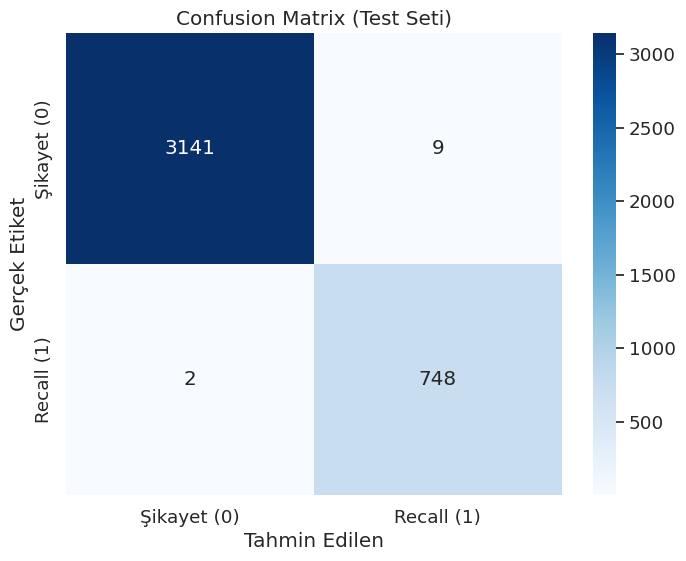

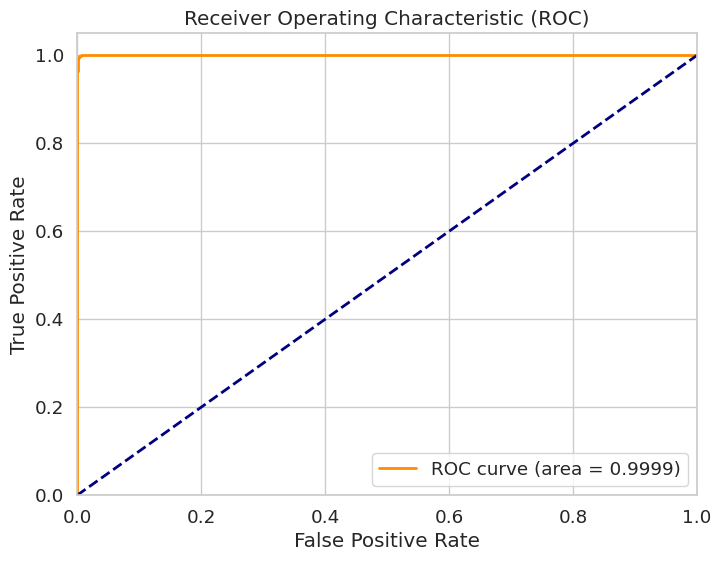


TEST Accuracy: 0.9972
TEST F1 Score: 0.9927
AUC Score: 0.9999
NOT: Eğitim sırasında en iyi sonuç veren model 'bert_checkpoints' klasöründe geçici olarak tutuluyor.
Grafikleri beğendiyseniz 'trainer.save_model()' komutu ile kalıcı olarak kaydedebiliriz.


In [3]:
# @title ADIM 3: Gelişmiş Eğitim ve Görselleştirme
# Bu kod:
# 1. Veriyi %70-%15-%15 böler.
# 2. Modeli eğitir (Overfitting önlemleriyle).
# 3. Sonuçları Confusion Matrix ve ROC Eğrisi ile görselleştirir.

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_curve, auc
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from datasets import Dataset
import torch.nn.functional as F

# Görselleştirme ayarları
%matplotlib inline
sns.set(style='whitegrid', palette='muted', font_scale=1.2)

# --- 1. VERİ YÜKLEME ---
print("[1/6] Veri yükleniyor...")
path = '/content/drive/MyDrive/Bottleneck/MASTER_DATA_CLEAN.csv'
df = pd.read_csv(path)

# Etiketleme
df['label'] = df['Kaynak'].apply(lambda x: 1 if x == 'RECALL' else 0)
df = df[['Temiz_Metin', 'label']].dropna()
df['Temiz_Metin'] = df['Temiz_Metin'].astype(str)

print(f"   -> Toplam Veri: {len(df)}")

# --- 2. DENGELİ BÖLME (%70 - %15 - %15) ---
print("\n[2/6] Veri setleri bölünüyor (Stratified)...")

# 1. Adım: %70 Train, %30 Geçici (Temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    df['Temiz_Metin'], df['label'],
    test_size=0.30,
    random_state=42,
    stratify=df['label'] # Dengeli dağılım sağlar
)

# 2. Adım: %30'luk kısmı ikiye böl -> %15 Val, %15 Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Dataset formatına çevir
train_dataset = Dataset.from_pandas(pd.DataFrame({'text': X_train, 'label': y_train}))
val_dataset = Dataset.from_pandas(pd.DataFrame({'text': X_val, 'label': y_val}))
test_dataset = Dataset.from_pandas(pd.DataFrame({'text': X_test, 'label': y_test}))

print(f"   -> Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

# --- 3. TOKENIZATION ---
print("\n[3/6] Tokenizer hazırlanıyor...")
model_name = "dbmdz/bert-base-turkish-cased"
tokenizer = BertTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# --- 4. EĞİTİM AYARLARI ---
print("\n[4/6] Model yapılandırılıyor...")
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=2)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Bottleneck/bert_checkpoints", # Geçici kayıt yeri
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,               # Overfitting önleyici
    logging_steps=50,
    eval_strategy="epoch",     # Her epoch sonu ölç
    save_strategy="epoch",           # Her epoch sonu kaydet
    load_best_model_at_end=True,     # En iyi versiyonu geri yükle (UNDERFITTING/OVERFITTING koruması)
    metric_for_best_model="f1",
    save_total_limit=1               # Sadece en iyiyi tut
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

# --- 5. EĞİTİMİ BAŞLAT ---
print("\n[5/6] EĞİTİM BAŞLIYOR...")
trainer.train()

# --- 6. GÖRSELLEŞTİRME VE TEST ---
print("\n[6/6] GÖRSELLEŞTİRME VE ANALİZ...")

# Test seti üzerinde tahmin al
predictions = trainer.predict(tokenized_test)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# Olasılıkları hesapla (ROC eğrisi için gerekli)
probs = F.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()[:, 1]

# 1. CONFUSION MATRIX (KARMAŞIKLIK MATRİSİ)
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Şikayet (0)', 'Recall (1)'], yticklabels=['Şikayet (0)', 'Recall (1)'])
plt.ylabel('Gerçek Etiket')
plt.xlabel('Tahmin Edilen')
plt.title('Confusion Matrix (Test Seti)')
plt.show()

# 2. ROC CURVE & AUC
fpr, tpr, thresholds = roc_curve(labels, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

print("\n" + "="*60)
print(f"TEST Accuracy: {accuracy_score(labels, preds):.4f}")
print(f"TEST F1 Score: {precision_recall_fscore_support(labels, preds, average='binary')[2]:.4f}")
print(f"AUC Score: {roc_auc:.4f}")
print("="*60)

# Kayıt uyarısı
print("NOT: Eğitim sırasında en iyi sonuç veren model 'bert_checkpoints' klasöründe geçici olarak tutuluyor.")
print("Grafikleri beğendiyseniz 'trainer.save_model()' komutu ile kalıcı olarak kaydedebiliriz.")

✅ Kullanılan Cihaz: CUDA
✅ Veri yüklendi. Toplam satır: 5000

📊 Kategori Dağılımı:
Sistem_Etiketi
Motor ve Yakıt               2115
Elektrik ve Yazılım           805
Fren Sistemi                  662
Diğer / Genel                 657
Lastik ve Jant                270
Direksiyon ve Süspansiyon     183
Gövde ve Donanım              179
Güvenlik Ekipmanları          129
Name: count, dtype: int64


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dbmdz/bert-base-turkish-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🚀 Sınıflandırma Modeli Eğitiliyor...


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.517195,0.858000
2,0.717400,0.329757,0.902000
3,0.717400,0.298186,0.920000



--- Confusion Matrix Oluşturuluyor ---


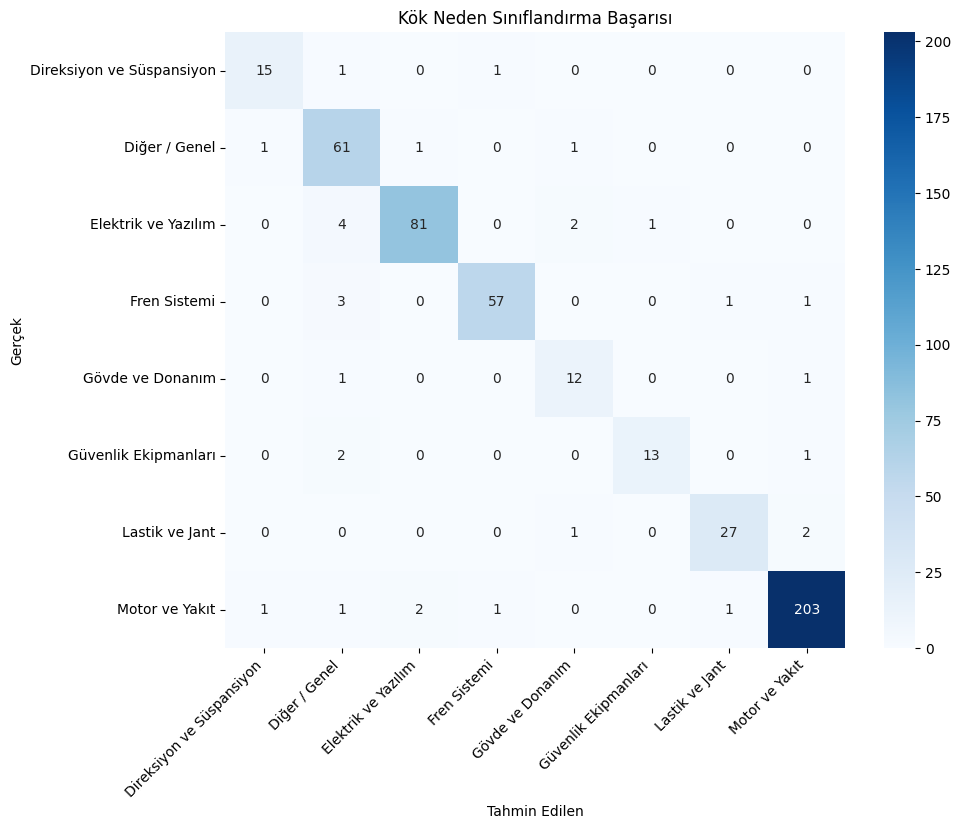


💾 Model ve Tokenizer kaydediliyor: /content/drive/MyDrive/Bottleneck/Kayitli_Modeller/BERT_Siniflandirici


Device set to use cuda:0


✅ Kayıt Başarılı! Bu modeli artık istediğin zaman çağırabilirsin.

--- 🧪 Canlı Test (Hızlı Kontrol) ---
Sorun: Araç seyir halindeyken direksiyon titreme yapıyor ve sağa çekiyor.
Tahmin: Elektrik ve Yazılım (Skor: 0.3536)


In [22]:
# @title 🏆 1. Aşama: Kök Neden Sınıflandırma Modeli (Eğitim ve Kaydetme)
# Gerekli kütüphaneleri sessiz modda yüklüyoruz.
!pip install transformers datasets evaluate accelerate scikit-learn seaborn matplotlib nltk rouge_score sentencepiece --quiet

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline
)
import evaluate
import nltk
import warnings

# Uyarıları filtrele
warnings.filterwarnings("ignore")
nltk.download('punkt', quiet=True)

# Cihaz ayarı
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Kullanılan Cihaz: {device.upper()}")

# ---------------------------------------------------------
# 1. VERİ YÜKLEME
# ---------------------------------------------------------
file_path = '/content/drive/MyDrive/Bottleneck/RECALL_VERISI_5000_TR.csv'

try:
    df = pd.read_csv(file_path)
    print(f"✅ Veri yüklendi. Toplam satır: {len(df)}")
except FileNotFoundError:
    print("❌ Dosya bulunamadı! Lütfen dosya yolunu kontrol edin.")
    raise

# Temizlik
df = df.dropna(subset=['Kök_Neden_TR', 'Çözüm_TR']).reset_index(drop=True)

# ---------------------------------------------------------
# 2. ETİKETLEME (LABELING)
# ---------------------------------------------------------
def categorize_issue(text):
    text = str(text).lower()
    if any(x in text for x in ['fren', 'brake', 'abs', 'hidrolik', 'pedal']):
        return 'Fren Sistemi'
    elif any(x in text for x in ['motor', 'engine', 'yakıt', 'gaz', 'emisyon', 'soğutma', 'şanzıman']):
        return 'Motor ve Yakıt'
    elif any(x in text for x in ['yazılım', 'software', 'ekran', 'gösterge', 'bilgisayar', 'sensör', 'elektrik', 'akü']):
        return 'Elektrik ve Yazılım'
    elif any(x in text for x in ['lastik', 'tekerlek', 'jant', 'tire']):
        return 'Lastik ve Jant'
    elif any(x in text for x in ['hava yastığı', 'airbag', 'kemer', 'emniyet']):
        return 'Güvenlik Ekipmanları'
    elif any(x in text for x in ['direksiyon', 'rot', 'aks', 'steering', 'süspansiyon']):
        return 'Direksiyon ve Süspansiyon'
    elif any(x in text for x in ['kapı', 'cam', 'gövde', 'şasi', 'kilit']):
        return 'Gövde ve Donanım'
    else:
        return 'Diğer / Genel'

df['Sistem_Etiketi'] = df['Kök_Neden_TR'].apply(categorize_issue)
label_list = sorted(list(df['Sistem_Etiketi'].unique()))
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for i, l in enumerate(label_list)}

df['label'] = df['Sistem_Etiketi'].map(label2id)

print("\n📊 Kategori Dağılımı:")
print(df['Sistem_Etiketi'].value_counts())

# Train/Test Ayrımı
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(test_df, test_size=0.5, random_state=42)

hf_data = DatasetDict({
    'train': Dataset.from_pandas(train_df),
    'validation': Dataset.from_pandas(val_df),
    'test': Dataset.from_pandas(test_df)
})

# ---------------------------------------------------------
# 3. MODEL EĞİTİMİ (BERT)
# ---------------------------------------------------------
model_ckpt_cls = "dbmdz/bert-base-turkish-cased"
tokenizer_cls = AutoTokenizer.from_pretrained(model_ckpt_cls)

def preprocess_cls(examples):
    return tokenizer_cls(examples["Kök_Neden_TR"], truncation=True, padding="max_length", max_length=128)

tokenized_cls = hf_data.map(preprocess_cls, batched=True)

model_cls = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt_cls, num_labels=len(label_list), id2label=id2label, label2id=label2id
).to(device)

args_cls = TrainingArguments(
    output_dir="bert-root-cause-classifier",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=True,
    report_to="none"
)

def compute_metrics_cls(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}

trainer_cls = Trainer(
    model=model_cls,
    args=args_cls,
    train_dataset=tokenized_cls["train"],
    eval_dataset=tokenized_cls["validation"],
    tokenizer=tokenizer_cls,
    compute_metrics=compute_metrics_cls,
)

print("\n🚀 Sınıflandırma Modeli Eğitiliyor...")
trainer_cls.train()

# ---------------------------------------------------------
# 4. DEĞERLENDİRME VE GÖRSELLEŞTİRME
# ---------------------------------------------------------
print("\n--- Confusion Matrix Oluşturuluyor ---")
predictions = trainer_cls.predict(tokenized_cls["test"])
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_list, yticklabels=label_list)
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.title('Kök Neden Sınıflandırma Başarısı')
plt.xticks(rotation=45, ha='right')
plt.show()

# ---------------------------------------------------------
# 5. MODELİ KAYDETME (GOOGLE DRIVE)
# ---------------------------------------------------------
# Drive'da kaydedilecek klasör yolu
save_path = '/content/drive/MyDrive/Bottleneck/Kayitli_Modeller/BERT_Siniflandirici'

# Klasör yoksa oluştur
if not os.path.exists(save_path):
    os.makedirs(save_path)

print(f"\n💾 Model ve Tokenizer kaydediliyor: {save_path}")
trainer_cls.save_model(save_path)
tokenizer_cls.save_pretrained(save_path)

print("✅ Kayıt Başarılı! Bu modeli artık istediğin zaman çağırabilirsin.")

# ---------------------------------------------------------
# 6. CANLI TEST (KAYITLI MODEL İLE)
# ---------------------------------------------------------
print("\n--- 🧪 Canlı Test (Hızlı Kontrol) ---")
# Hızlı test için pipeline
classifier = pipeline("text-classification", model=model_cls, tokenizer=tokenizer_cls, device=0 if device=="cuda" else -1)

sample_text = "Araç seyir halindeyken direksiyon titreme yapıyor ve sağa çekiyor."
result = classifier(sample_text)

print(f"Sorun: {sample_text}")
print(f"Tahmin: {result[0]['label']} (Skor: {result[0]['score']:.4f})")

✅ Cihaz: CUDA
✅ Veri Seti Yüklendi: 5000 satır

📊 Sınıf Dağılımı (Makale İçin Önemli):
Sistem_Etiketi
Motor ve Güç Aktarma         2128
Elektrik ve Yazılım           868
Fren Sistemi                  662
Diğer / Genel                 548
Lastik ve Jant                267
Gövde ve Donanım              207
Direksiyon ve Süspansiyon     195
Güvenlik Ekipmanları          125
Name: count, dtype: int64


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

...

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dbmdz/bert-base-turkish-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🚀 Eğitim Başlıyor...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.669283,0.792000,0.780161
2,No log,0.443130,0.868000,0.867857
3,No log,0.339544,0.905000,0.906187
4,0.594600,0.323044,0.906000,0.906960



--- 🧪 Test Sonuçları Hesaplanıyor ---


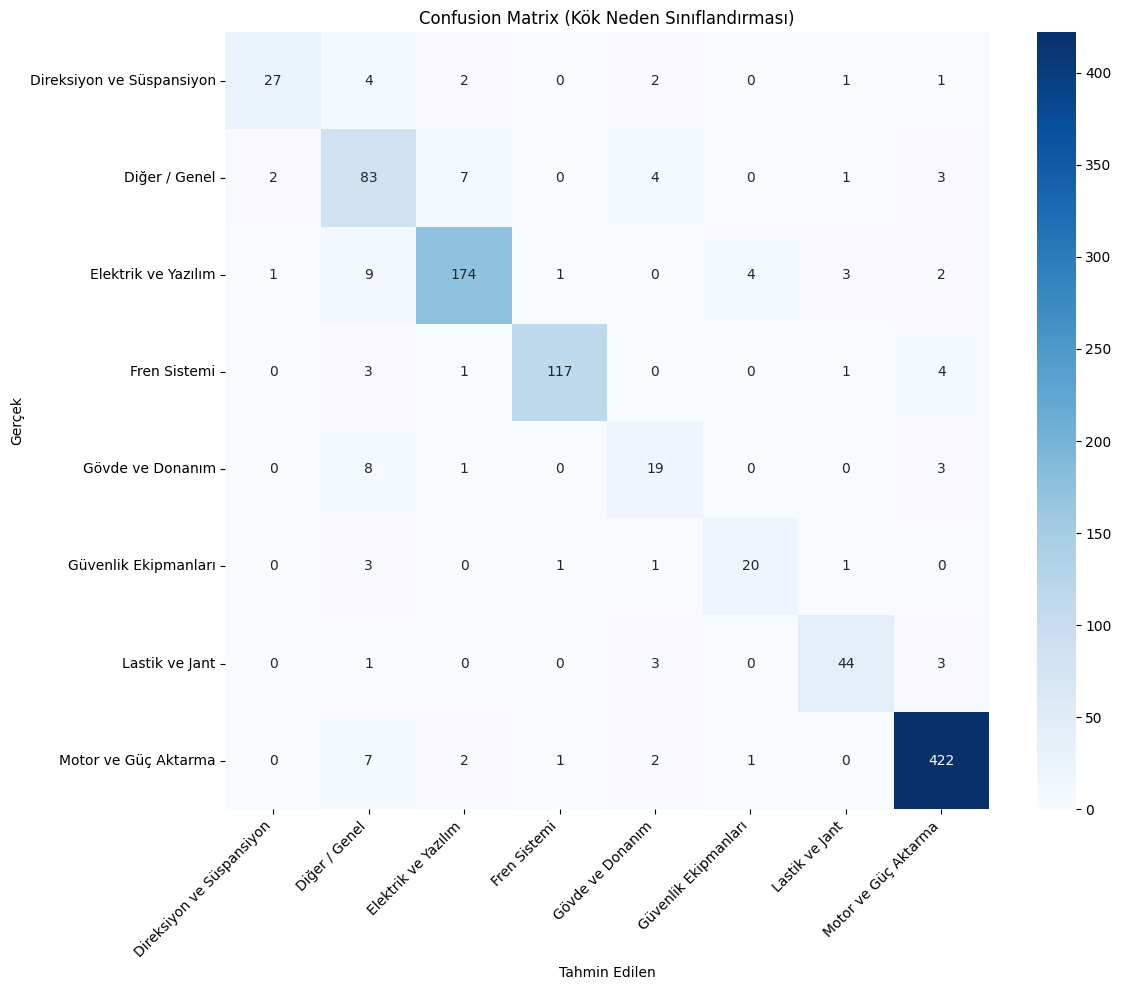


--- 📄 Sınıflandırma Raporu (Makaleye Eklenecek Tablo) ---
                           precision    recall  f1-score   support

Direksiyon ve Süspansiyon     0.9000    0.7297    0.8060        37
            Diğer / Genel     0.7034    0.8300    0.7615       100
      Elektrik ve Yazılım     0.9305    0.8969    0.9134       194
             Fren Sistemi     0.9750    0.9286    0.9512       126
         Gövde ve Donanım     0.6129    0.6129    0.6129        31
     Güvenlik Ekipmanları     0.8000    0.7692    0.7843        26
           Lastik ve Jant     0.8627    0.8627    0.8627        51
     Motor ve Güç Aktarma     0.9635    0.9701    0.9668       435

                 accuracy                         0.9060      1000
                macro avg     0.8435    0.8250    0.8323      1000
             weighted avg     0.9099    0.9060    0.9070      1000



Device set to use cuda:0



✅ Model başarıyla kaydedildi: /content/drive/MyDrive/Bottleneck/Kayitli_Modeller/BERT_Final_Classifier

--- 🔎 Canlı Deneme ---
Girdi: Araç ani fren yapıldığında sağa çekiyor ve ABS ışığı yanıyor.
Tahmin: Gövde ve Donanım (Güven: 0.2539)


In [3]:
# @title 🎓 Akademik Kök Neden Sınıflandırma Sistemi (BERT)
# Gerekli kütüphaneler
!pip install transformers datasets evaluate accelerate scikit-learn seaborn matplotlib --quiet

import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline
)
import warnings

# Ayarlar
warnings.filterwarnings("ignore")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Cihaz: {device.upper()}")

# ---------------------------------------------------------
# 1. VERİ YÜKLEME VE HAZIRLIK
# ---------------------------------------------------------
file_path = '/content/drive/MyDrive/Bottleneck/RECALL_VERISI_5000_TR.csv'

try:
    df = pd.read_csv(file_path)
    df = df.dropna(subset=['Kök_Neden_TR']).reset_index(drop=True)
    print(f"✅ Veri Seti Yüklendi: {len(df)} satır")
except Exception as e:
    print(f"❌ Hata: {e}")
    raise e

# --- ETİKETLEME (LABELING) ---
# Makalenizde: "Veri seti, uzman görüşüne dayalı anahtar kelime haritalaması ile 8 ana sınıfa ayrılmıştır." diyebilirsiniz.
def categorize_issue(text):
    text = str(text).lower()
    if any(x in text for x in ['fren', 'brake', 'abs', 'hidrolik', 'pedal', 'kaliper']):
        return 'Fren Sistemi'
    elif any(x in text for x in ['motor', 'engine', 'yakıt', 'gaz', 'emisyon', 'soğutma', 'şanzıman', 'egzoz']):
        return 'Motor ve Güç Aktarma'
    elif any(x in text for x in ['yazılım', 'software', 'ekran', 'gösterge', 'bilgisayar', 'sensör', 'elektrik', 'akü', 'kablo']):
        return 'Elektrik ve Yazılım'
    elif any(x in text for x in ['lastik', 'tekerlek', 'jant', 'tire', 'sibop']):
        return 'Lastik ve Jant'
    elif any(x in text for x in ['hava yastığı', 'airbag', 'kemer', 'emniyet', 'tokalar']):
        return 'Güvenlik Ekipmanları'
    elif any(x in text for x in ['direksiyon', 'rot', 'aks', 'steering', 'süspansiyon', 'yay']):
        return 'Direksiyon ve Süspansiyon'
    elif any(x in text for x in ['kapı', 'cam', 'gövde', 'şasi', 'kilit', 'ayna', 'silecek']):
        return 'Gövde ve Donanım'
    else:
        return 'Diğer / Genel'

df['Sistem_Etiketi'] = df['Kök_Neden_TR'].apply(categorize_issue)

# Etiketleri Sayısala Çevirme
label_list = sorted(list(df['Sistem_Etiketi'].unique()))
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for i, l in enumerate(label_list)}
df['label'] = df['Sistem_Etiketi'].map(label2id)

print("\n📊 Sınıf Dağılımı (Makale İçin Önemli):")
print(df['Sistem_Etiketi'].value_counts())

# Dataset Bölme (%80 Eğitim, %20 Test)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
hf_data = DatasetDict({
    'train': Dataset.from_pandas(train_df),
    'test': Dataset.from_pandas(test_df)
})

# ---------------------------------------------------------
# 2. MODEL EĞİTİMİ (BERT)
# ---------------------------------------------------------
# Türkçe için en iyi BERT modellerinden biri
model_ckpt = "dbmdz/bert-base-turkish-cased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

def preprocess_function(examples):
    return tokenizer(examples["Kök_Neden_TR"], truncation=True, padding="max_length", max_length=128)

tokenized_data = hf_data.map(preprocess_function, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt, num_labels=len(label_list), id2label=id2label, label2id=label2id
).to(device)

# Akademik Metrikler Fonksiyonu
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')

    return {"accuracy": acc, "f1": f1}

args = TrainingArguments(
    output_dir="bert-classifier-academic",
    learning_rate=2e-5,
    per_device_train_batch_size=32, # A100/T4 için uygun
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True, # Hızlandırma
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_data["train"],
    eval_dataset=tokenized_data["test"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

print("\n🚀 Eğitim Başlıyor...")
trainer.train()

# ---------------------------------------------------------
# 3. AKADEMİK RAPORLAMA VE GÖRSELLEŞTİRME
# ---------------------------------------------------------
print("\n--- 🧪 Test Sonuçları Hesaplanıyor ---")
predictions = trainer.predict(tokenized_data["test"])
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

# 1. Confusion Matrix (Görsel)
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_list, yticklabels=label_list)
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.title('Confusion Matrix (Kök Neden Sınıflandırması)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Classification Report (Metin)
print("\n--- 📄 Sınıflandırma Raporu (Makaleye Eklenecek Tablo) ---")
print(classification_report(labels, preds, target_names=label_list, digits=4))

# ---------------------------------------------------------
# 4. MODELİ KAYDETME
# ---------------------------------------------------------
save_path = '/content/drive/MyDrive/Bottleneck/Kayitli_Modeller/BERT_Final_Classifier'
if not os.path.exists(save_path): os.makedirs(save_path)

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f"\n✅ Model başarıyla kaydedildi: {save_path}")

# ---------------------------------------------------------
# 5. KÖR TEST (Canlı Deneme)
# ---------------------------------------------------------
print("\n--- 🔎 Canlı Deneme ---")
pipe = pipeline("text-classification", model=model, tokenizer=tokenizer, device=0 if device=="cuda" else -1)
sample_text = "Araç ani fren yapıldığında sağa çekiyor ve ABS ışığı yanıyor."
result = pipe(sample_text)
print(f"Girdi: {sample_text}")
print(f"Tahmin: {result[0]['label']} (Güven: {result[0]['score']:.4f})")

In [6]:
# @title 🧠 Hata Düzeltildi: Kayıtlı Modeli Yükle ve 100 Örnekle Test Et
# Gerekli kütüphaneler
!pip install transformers torch pandas scikit-learn --quiet

import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import os
from google.colab import drive

# 1. DRIVE BAĞLANTISI
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. AYARLAR
model_path = '/content/drive/MyDrive/Bottleneck/Kayitli_Modeller/BERT_Final_Classifier'
data_path = '/content/drive/MyDrive/Bottleneck/RECALL_VERISI_5000_TR.csv'

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Cihaz: {device.upper()}")

# 3. MODELİ YÜKLEME
if os.path.exists(model_path):
    print(f"📂 Model yükleniyor: {model_path}...")
    try:
        # Tokenizer'ı yüklerken de ayarları belirtelim
        loaded_tokenizer = AutoTokenizer.from_pretrained(model_path, model_max_length=512)
        loaded_model = AutoModelForSequenceClassification.from_pretrained(model_path).to(device)

        # Pipeline oluştururken tokenizer'ı açıkça veriyoruz
        classifier = pipeline("text-classification", model=loaded_model, tokenizer=loaded_tokenizer, device=0 if device=="cuda" else -1)
        print("✅ Model başarıyla yüklendi!")
    except Exception as e:
        print(f"❌ Model yüklenirken hata: {e}")
        raise e
else:
    raise FileNotFoundError("Model klasörü bulunamadı.")

# 4. 100 ÖRNEK SEÇİMİ
print("\n📊 Veri setinden 100 rastgele örnek seçiliyor...")
df = pd.read_csv(data_path)
df = df.dropna(subset=['Kök_Neden_TR'])

# Etiketleme Fonksiyonu (Kıyaslama için)
def categorize_issue(text):
    text = str(text).lower()
    if any(x in text for x in ['fren', 'brake', 'abs', 'hidrolik']): return 'Fren Sistemi'
    if any(x in text for x in ['motor', 'engine', 'yakıt', 'gaz']): return 'Motor ve Güç Aktarma'
    if any(x in text for x in ['yazılım', 'elektrik', 'sensör']): return 'Elektrik ve Yazılım'
    if any(x in text for x in ['lastik', 'jant', 'tekerlek']): return 'Lastik ve Jant'
    if any(x in text for x in ['hava yastığı', 'kemer']): return 'Güvenlik Ekipmanları'
    if any(x in text for x in ['direksiyon', 'rot', 'aks']): return 'Direksiyon ve Süspansiyon'
    if any(x in text for x in ['kapı', 'gövde', 'şasi']): return 'Gövde ve Donanım'
    return 'Diğer / Genel'

sample_df = df.sample(n=100, random_state=42).reset_index(drop=True)
sample_df['Gerçek_Etiket'] = sample_df['Kök_Neden_TR'].apply(categorize_issue)

# 5. TAHMİN YAPMA (DÜZELTME BURADA)
print("🚀 Tahminler yapılıyor...")

predictions = []
confidences = []

# --- HATA ÇÖZÜMÜ: truncation=True ve max_length=512 EKLENDİ ---
# Bu sayede 512 kelimeden uzun şikayetler otomatik kesilir ve hata vermez.
results = classifier(
    sample_df['Kök_Neden_TR'].tolist(),
    batch_size=16,
    truncation=True,
    max_length=512
)

for res in results:
    predictions.append(res['label'])
    confidences.append(res['score'])

sample_df['Model_Tahmini'] = predictions
sample_df['Guven_Skoru'] = confidences

# 6. SONUÇLARI GÖSTERME
sample_df['Durum'] = sample_df.apply(lambda x: '✅ DOĞRU' if x['Gerçek_Etiket'] == x['Model_Tahmini'] else '❌ YANLIŞ', axis=1)

accuracy = (sample_df['Durum'] == '✅ DOĞRU').mean() * 100
print(f"\n🏆 100 Örnek Üzerindeki Başarı: %{accuracy:.2f}")

print("\n--- ⚠️ Hata Analizi (Modelin Yanıldığı Durumlar) ---")
errors = sample_df[sample_df['Durum'] == '❌ YANLIŞ']
if not errors.empty:
    for idx, row in errors.head(5).iterrows():
        print(f"Sorun: {row['Kök_Neden_TR'][:100]}...")
        print(f"Gerçek: {row['Gerçek_Etiket']} | Tahmin: {row['Model_Tahmini']} (Güven: {row['Guven_Skoru']:.2f})")
        print("-" * 50)
else:
    print("Tebrikler! Model hiç hata yapmadı.")

# İlk 10 Sonuç
print("\n--- 📋 İlk 10 Tahmin ---")
print(sample_df[['Kök_Neden_TR', 'Gerçek_Etiket', 'Model_Tahmini', 'Durum']].head(10).to_markdown(index=False))

✅ Cihaz: CUDA
📂 Model yükleniyor: /content/drive/MyDrive/Bottleneck/Kayitli_Modeller/BERT_Final_Classifier...


Device set to use cuda:0


✅ Model başarıyla yüklendi!

📊 Veri setinden 100 rastgele örnek seçiliyor...
🚀 Tahminler yapılıyor...

🏆 100 Örnek Üzerindeki Başarı: %90.00

--- ⚠️ Hata Analizi (Modelin Yanıldığı Durumlar) ---
Sorun: ANA GÜÇ KABLOSU SÜRTÜNME NEDENİYLE AŞINABİLİR....
Gerçek: Diğer / Genel | Tahmin: Elektrik ve Yazılım (Güven: 0.51)
--------------------------------------------------
Sorun: New Flyer of America, Inc. (New Flyer), isteğe bağlı yangın söndürme sisteminin bir parçası olarak b...
Gerçek: Diğer / Genel | Tahmin: Lastik ve Jant (Güven: 0.87)
--------------------------------------------------
Sorun: ARAÇ TANIMI: SAS SENSÖR ÜNİTESİ İLE DONATILAN BİNEK ARAÇLAR.  BU ARAÇLARDA KÜÇÜK ALT TAKIM DARBELERİ...
Gerçek: Elektrik ve Yazılım | Tahmin: Diğer / Genel (Güven: 0.81)
--------------------------------------------------
Sorun: ARAÇ TANIMI: 45 AMP MIKNATIS GÜÇ DÖNÜŞTÜRÜCÜLERİ İLE DONATILMIŞ EĞLENCE ARAÇLARI.  KONVERTÖRÜN BASKI...
Gerçek: Diğer / Genel | Tahmin: Elektrik ve Yazılım (Güven: 0.87)
---

✅ Cihaz: CUDA

📊 Veri seti ve Model yükleniyor...


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

🚀 Test seti üzerinde tahminler alınıyor...


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"



🏆 GENEL BAŞARI (ACCURACY): %89.30
⚖️ DENGELİ SKOR (F1-SCORE): 0.8925


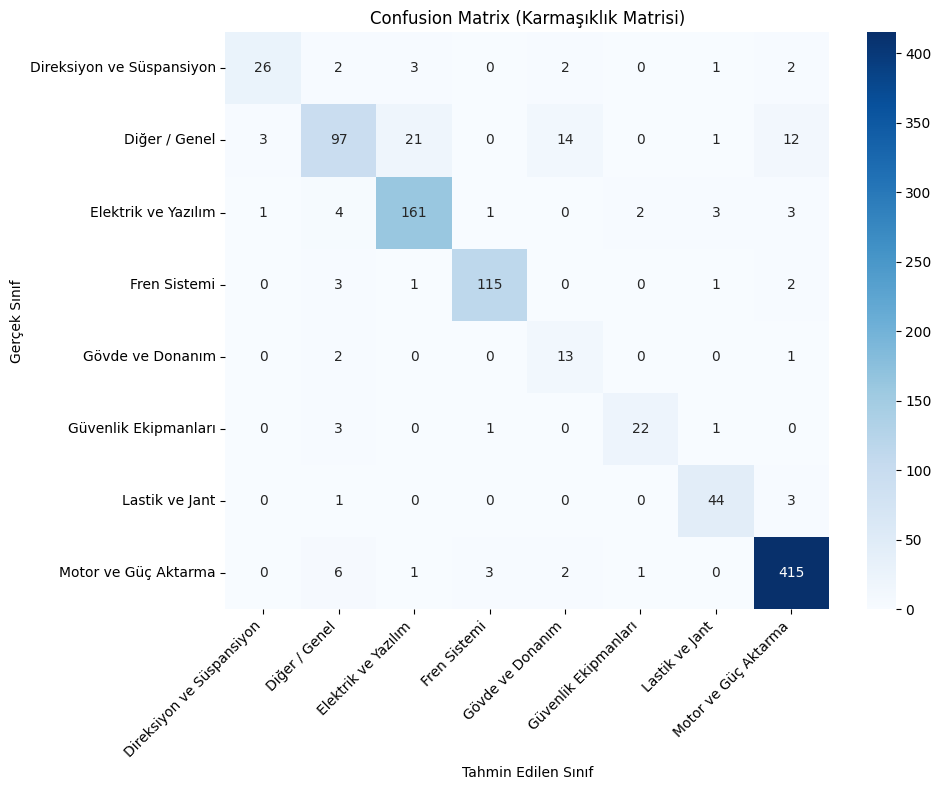

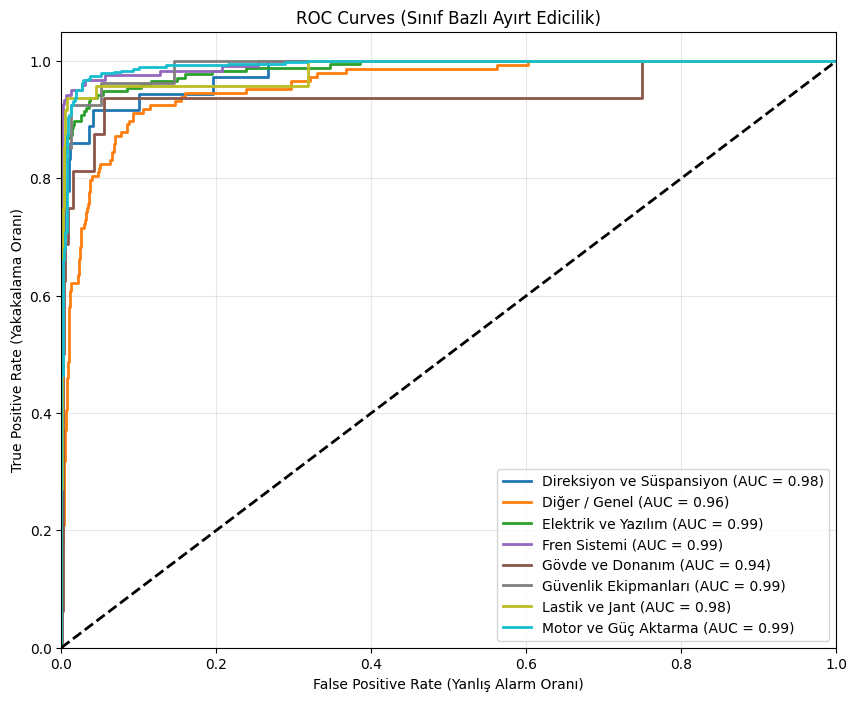


--- 🧐 SINIF BAZLI PERFORMANS VE BIAS ANALİZİ ---
|                           |   precision |   recall |   f1-score |   support |
|:--------------------------|------------:|---------:|-----------:|----------:|
| Motor ve Güç Aktarma      |    0.947489 | 0.969626 |   0.95843  |       428 |
| Fren Sistemi              |    0.958333 | 0.942623 |   0.950413 |       122 |
| Elektrik ve Yazılım       |    0.860963 | 0.92     |   0.889503 |       175 |
| Lastik ve Jant            |    0.862745 | 0.916667 |   0.888889 |        48 |
| Güvenlik Ekipmanları      |    0.88     | 0.814815 |   0.846154 |        27 |
| Direksiyon ve Süspansiyon |    0.866667 | 0.722222 |   0.787879 |        36 |
| Diğer / Genel             |    0.822034 | 0.655405 |   0.729323 |       148 |
| Gövde ve Donanım          |    0.419355 | 0.8125   |   0.553191 |        16 |

🔍 BIAS YORUMU:
- Model 'Motor ve Güç Aktarma' sınıfında en yüksek başarıyı gösteriyor (F1: 0.96).
- Model 'Gövde ve Donanım' sınıfında zorlanıyor (F1

In [7]:
# @title 🎓 Akademik Performans Değerlendirme Modülü (Final Rapor)
# Gerekli kütüphaneler
!pip install transformers torch pandas scikit-learn seaborn matplotlib --quiet

import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_fscore_support
)
from sklearn.preprocessing import label_binarize
from google.colab import drive
import os
import warnings

# Ayarlar
warnings.filterwarnings("ignore")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Cihaz: {device.upper()}")

# 1. BAĞLANTILAR
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

model_path = '/content/drive/MyDrive/Bottleneck/Kayitli_Modeller/BERT_Final_Classifier'
data_path = '/content/drive/MyDrive/Bottleneck/RECALL_VERISI_5000_TR.csv'

# 2. VERİ HAZIRLIĞI
print("\n📊 Veri seti ve Model yükleniyor...")
df = pd.read_csv(data_path)
df = df.dropna(subset=['Kök_Neden_TR'])

# Etiketleme Fonksiyonu (Ground Truth)
def categorize_issue(text):
    text = str(text).lower()
    if any(x in text for x in ['fren', 'brake', 'abs', 'hidrolik']): return 'Fren Sistemi'
    if any(x in text for x in ['motor', 'engine', 'yakıt', 'gaz']): return 'Motor ve Güç Aktarma'
    if any(x in text for x in ['yazılım', 'elektrik', 'sensör']): return 'Elektrik ve Yazılım'
    if any(x in text for x in ['lastik', 'jant', 'tekerlek']): return 'Lastik ve Jant'
    if any(x in text for x in ['hava yastığı', 'kemer']): return 'Güvenlik Ekipmanları'
    if any(x in text for x in ['direksiyon', 'rot', 'aks']): return 'Direksiyon ve Süspansiyon'
    if any(x in text for x in ['kapı', 'gövde', 'şasi']): return 'Gövde ve Donanım'
    return 'Diğer / Genel'

df['Sistem_Etiketi'] = df['Kök_Neden_TR'].apply(categorize_issue)
label_list = sorted(list(df['Sistem_Etiketi'].unique()))
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for i, l in enumerate(label_list)}
df['label'] = df['Sistem_Etiketi'].map(label2id)

# Test Seti (%20 - Eğitimde kullanılanın aynısı olması için random_state=42)
from sklearn.model_selection import train_test_split
_, test_df = train_test_split(df, test_size=0.2, random_state=42)

# HuggingFace Dataset
from datasets import Dataset
test_dataset = Dataset.from_pandas(test_df)

# 3. MODELİ YÜKLEME
tokenizer = AutoTokenizer.from_pretrained(model_path, model_max_length=512)
model = AutoModelForSequenceClassification.from_pretrained(model_path).to(device)

def preprocess_function(examples):
    return tokenizer(examples["Kök_Neden_TR"], truncation=True, padding="max_length", max_length=128)

tokenized_test = test_dataset.map(preprocess_function, batched=True)

# 4. TAHMİN (OLASILIKLARLA BERABER)
print("🚀 Test seti üzerinde tahminler alınıyor...")
trainer = Trainer(model=model)
predictions = trainer.predict(tokenized_test)
preds_probs = torch.nn.functional.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()
preds = np.argmax(preds_probs, axis=1)
labels = predictions.label_ids

# ---------------------------------------------------------
# RAPOR 1: GENEL METRİKLER
# ---------------------------------------------------------
acc = accuracy_score(labels, preds)
f1 = f1_score(labels, preds, average='weighted')
print(f"\n🏆 GENEL BAŞARI (ACCURACY): %{acc*100:.2f}")
print(f"⚖️ DENGELİ SKOR (F1-SCORE): {f1:.4f}")

# ---------------------------------------------------------
# RAPOR 2: CONFUSION MATRIX (GÖRSEL)
# ---------------------------------------------------------
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_list, yticklabels=label_list)
plt.title('Confusion Matrix (Karmaşıklık Matrisi)')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Confusion_Matrix_Academic.png', dpi=300) # Kaydeder
plt.show()

# ---------------------------------------------------------
# RAPOR 3: ROC EĞRİSİ ve AUC (ÇOK ÖNEMLİ)
# ---------------------------------------------------------
# Çok sınıflı ROC için sınıfları binarize etmemiz lazım
y_test_bin = label_binarize(labels, classes=range(len(label_list)))
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', n_classes)

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], preds_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors(i), lw=2,
             label=f'{label_list[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Yanlış Alarm Oranı)')
plt.ylabel('True Positive Rate (Yakakalama Oranı)')
plt.title('ROC Curves (Sınıf Bazlı Ayırt Edicilik)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig('ROC_Curve_Academic.png', dpi=300)
plt.show()

# ---------------------------------------------------------
# RAPOR 4: BIAS VE DETAYLI PERFORMANS ANALİZİ
# ---------------------------------------------------------
print("\n--- 🧐 SINIF BAZLI PERFORMANS VE BIAS ANALİZİ ---")
report = classification_report(labels, preds, target_names=label_list, output_dict=True)
bias_df = pd.DataFrame(report).transpose()

# Bias Yorumu İçin Tablo Düzenleme
bias_df = bias_df.drop(['accuracy', 'macro avg', 'weighted avg'])
bias_df = bias_df.sort_values(by='f1-score', ascending=False)

print(bias_df[['precision', 'recall', 'f1-score', 'support']].to_markdown())

print("\n🔍 BIAS YORUMU:")
en_kotu = bias_df.index[-1]
en_iyi = bias_df.index[0]
print(f"- Model '{en_iyi}' sınıfında en yüksek başarıyı gösteriyor (F1: {bias_df.loc[en_iyi, 'f1-score']:.2f}).")
print(f"- Model '{en_kotu}' sınıfında zorlanıyor (F1: {bias_df.loc[en_kotu, 'f1-score']:.2f}).")
print("  (Düşük sınıflar genellikle veri setindeki örnek azlığından kaynaklanır, buna 'Data Imbalance Bias' denir.)")

# Sonuçları CSV yapıp indirelim
bias_df.to_csv('Akademik_Sonuc_Tablosu.csv')
print("\n💾 Tüm metrikler 'Akademik_Sonuc_Tablosu.csv' dosyasına kaydedildi.")